In [29]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
import pandas as pd
import shap
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv('nBodyData.csv')

X = data.drop('GPU', axis=1)
y = data['GPU']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_log = np.log(y_train)

cols = ['total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

features = ['elements', 'blocks', 'threadsPerBlock',
       'total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

device_specs = data[cols].drop_duplicates().to_numpy()

#device_specs[0] = cuda2
#device_specs[1] = cuda3
#device_specs[2] = cuda4
#device_specs[3] = cuda5

In [31]:
model = XGBRegressor(
    n_estimators=10000,        # Reduce the number of trees
    max_depth=8,            # Minimal tree depth
    learning_rate=0.1,     # Decrease learning rate
    # reg_alpha=1.0,          # Add L1 regularization
    # reg_lambda=1.0,         # Add L2 regularization
    # subsample=0.8,
    # colsample_bytree=1, 
    random_state=42
)
model.fit(X_train, y_log) #train on y_log instead of y_train to restrict the predicted compute times to be >0

preds_log = model.predict(X_test)
preds = np.exp(preds_log) #revert back from log of predicted time
preds[:6], y_test.to_numpy()[:6]

(array([ 2.03832 ,  1.842798, 19.239794, 90.67089 , 33.696125,  8.196942],
       dtype=float32),
 array([ 1.698479,  1.908451, 18.876191, 91.411323, 36.809446,  8.673378]))

In [33]:
# Normalize time and predictions as a percentage of the maximum execution time for each "problem_size"
X_test["GPU"] = y_test
X_test["pred"] = preds
# Group by "problem_size" and compute normalization factor (max)
grouped_max_time = X_test.groupby("elements")["GPU"].transform("max")

# Normalize actual time as a percentage of the max
X_test["normalized_time"] = (X_test["GPU"] / grouped_max_time) * 100

# Group by "problem_size" and compute normalization factor (max) for predictions
grouped_max_preds = X_test.groupby("elements")["pred"].transform("max")

# Normalize predictions as a percentage of the max
X_test["normalized_pred"] = (X_test["pred"] / grouped_max_time) * 100

# Extract normalized predictions as a NumPy array (if needed)
normalized_preds = X_test["normalized_pred"].values

# # Calculate absolute error
# X_test["absolute_error"] = np.abs(X_test["normalized_pred"] - X_test["normalized_time"])

# # Group by "problem_size" and calculate MAE
# mae_by_group = X_test.groupby("image_size")["absolute_error"].mean()

# # Convert results to a DataFrame for display
# mae_results = mae_by_group.reset_index()
# mae_results.columns = ["image_size", "MAE"]

# # Display the results
# print(mae_results)


In [35]:
X_test['blocks_threads'] = X_test['blocks'] * X_test['threadsPerBlock']

# Sorting first by blocks * threadsPerBlock, then by elements
sorted_df = X_test.sort_values(by=['blocks_threads', 'elements'], ascending=[True, True]).reset_index(drop=True)


sorted_df.head()


,elements,threadsPerBlock,blocks,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM,GPU,pred,normalized_time,normalized_pred,blocks_threads
0,40960,64,1,11268608,1635000,68,3,352,7000000,5767168,1024,1.252121,1.211624,12.711607,12.300478,64
1,81920,64,1,12492800,1215500,24,2,384,3505000,3145728,2048,5.410296,5.534117,15.921691,16.286077,64
2,102400,64,1,12339264,1455000,80,7,3072,850000,4718592,2048,4.075972,4.139183,7.987720,8.111595,64
3,204800,64,1,12289920,2505000,46,2,192,10501000,37748736,1536,4.908098,4.835748,2.876855,2.834447,64
4,409600,64,1,12339264,1455000,80,7,3072,850000,4718592,2048,18.562279,18.699259,2.298119,2.315078,64


In [37]:
sorted_df1024 = sorted_df[sorted_df['elements']==102400]

sorted_aggregated_df = sorted_df.groupby(["elements",'blocks_threads']).mean().reset_index()
sorted_df1024aggregated_df = sorted_df1024.groupby(["elements",'blocks_threads']).mean().reset_index()


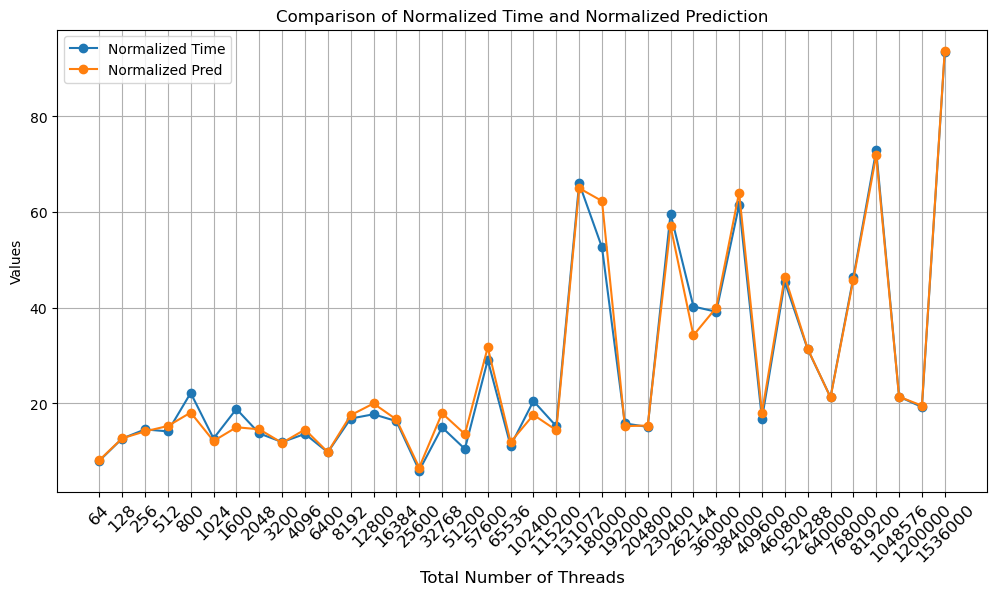

In [39]:
# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.plot(sorted_df1024aggregated_df['normalized_time'], label='Normalized Time', marker='o')
plt.plot(sorted_df1024aggregated_df['normalized_pred'], label='Normalized Pred', marker='o')
plt.xlabel('Total Number of Threads', fontsize=12)
plt.xticks(range(len(sorted_df1024aggregated_df['blocks_threads'])), sorted_df1024aggregated_df['blocks_threads'], fontsize=12, rotation=45)
# plt.xticks(ticks=sorted_df1024aggregated_df['blocks_threads'], labels="threads", )  # Attach x-axis labels

plt.ylabel('Values')
plt.title('Comparison of Normalized Time and Normalized Prediction')
plt.legend()
plt.grid(True)
plt.show()

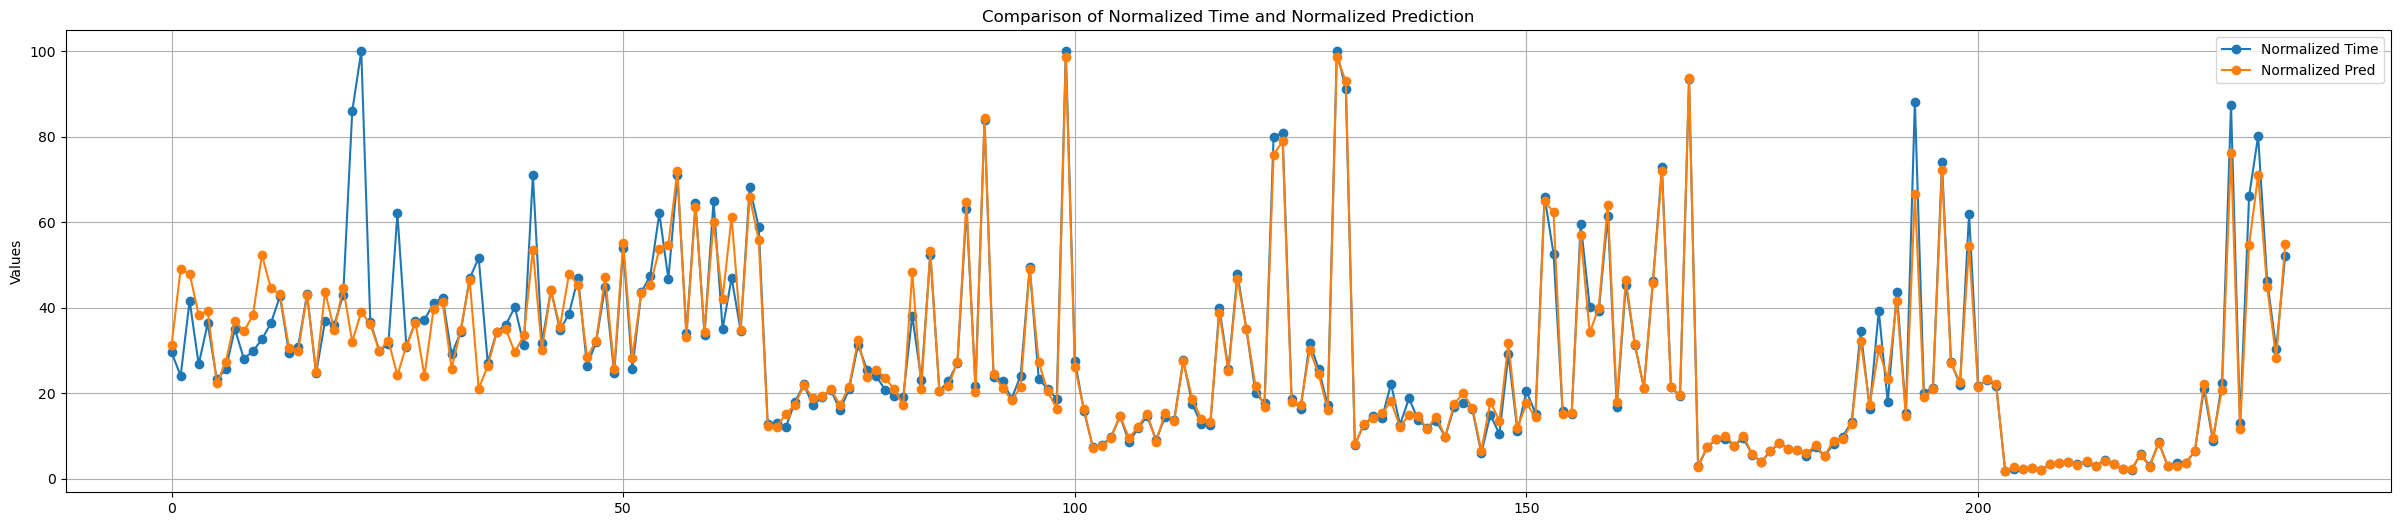

In [41]:
# Plotting the comparison
plt.figure(figsize=(30, 6))
plt.plot(sorted_aggregated_df['normalized_time'], label='Normalized Time', marker='o')
plt.plot(sorted_aggregated_df['normalized_pred'], label='Normalized Pred', marker='o')
# plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Normalized Time and Normalized Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
blocks = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 450, 512, 800, 1024, 1500])
threads = np.array([64, 128, 256, 400, 512, 800, 1024])

num_elements = 100000

results = []
for b in blocks:
    for t in threads:
            input_features = np.concatenate([np.array([num_elements, t, b], dtype='float64'), device_specs[0]]).reshape(-1, 11)

            res = np.exp(model.predict(input_features))

            results.append([t, b, res[0]])

results = np.array(results)

sorted = results[results[:, 2].argsort()]

min_tpb, min_b, min_time = results[np.argmin(results[:, 2])]
print(f'Best Config:')
print(f'Blocks: {int(min_b)} | Threads Per Block: {int(min_tpb)} | Time: {min_time:.6f}s')

print("\nBest device: cuda2")
print("Device Specs:\n")

for name, spec in zip(cols, device_specs[0]):
    print(f'{name}: {spec}')

Best Config:
Blocks: 4 | Threads Per Block: 64 | Time: 2.288692s

Best device: cuda2
Device Specs:

total global memory(KB): 11268608
clock rate(KHz): 1635000
multiprocessor count: 68
async engine count: 3
memory bus width: 352
memory clock rate (KHz): 7000000
L2 cache size (bytes): 5767168
max threads per SM: 1024


In [45]:
print('Top 10 Best Configurations:')

for s in range(10):
    tpb, nb, time = sorted[s]
    print(f'Blocks: {int(nb)} | Threads Per Block: {int(tpb)} | Time: {time:.6f}s')

Top 10 Best Configurations:
Blocks: 4 | Threads Per Block: 64 | Time: 2.288692s
Blocks: 16 | Threads Per Block: 64 | Time: 2.384549s
Blocks: 1 | Threads Per Block: 128 | Time: 2.413837s
Blocks: 2 | Threads Per Block: 128 | Time: 2.418073s
Blocks: 1 | Threads Per Block: 64 | Time: 2.418527s
Blocks: 8 | Threads Per Block: 64 | Time: 2.448682s
Blocks: 2 | Threads Per Block: 64 | Time: 2.454859s
Blocks: 16 | Threads Per Block: 128 | Time: 2.459163s
Blocks: 32 | Threads Per Block: 64 | Time: 2.459737s
Blocks: 8 | Threads Per Block: 128 | Time: 2.463107s


In [47]:
#Compare with Ground Truth for 10m Elements
# ground truth gathered by running many configurations of blocks and threadsPerBlock on CIMS servers
# with fixed number of elements for 20 iterations each and taking their mean stratified by configuration
# note: all GT configurations ran on the system with the best overall performance (cuda4 in this case)

gt = pd.read_csv('nbodyGT.csv')
gt = gt.groupby(['blocks', 'threadsPerBlock']).mean().reset_index().sort_values('GPU')
gt.head(10)

,blocks,threadsPerBlock,elements,GPU
14,4,64,100000.0,2.910407
21,8,64,100000.0,2.923885
7,2,64,100000.0,2.931870
0,1,64,100000.0,2.937146
1,1,128,100000.0,2.955249
49,128,64,100000.0,2.983417
15,4,128,100000.0,2.983581
22,8,128,100000.0,3.005980
35,32,64,100000.0,3.032347
8,2,128,100000.0,3.062799



Top 5 most important features (XGBoost):
                   Feature  Importance
2  total global memory(KB)    0.099864
1          threadsPerBlock    0.069451
3          clock rate(KHz)    0.046351
4     multiprocessor count    0.020159
0                   blocks    0.019429

Top 5 most important features (SHAP):
                   Feature  SHAP_Importance
1          threadsPerBlock         0.350666
2  total global memory(KB)         0.270677
0                   blocks         0.181629
3          clock rate(KHz)         0.079386
4     multiprocessor count         0.032804


<Figure size 1000x500 with 0 Axes>

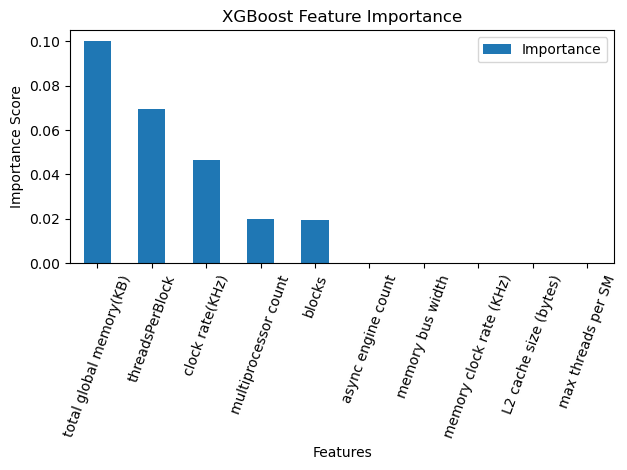

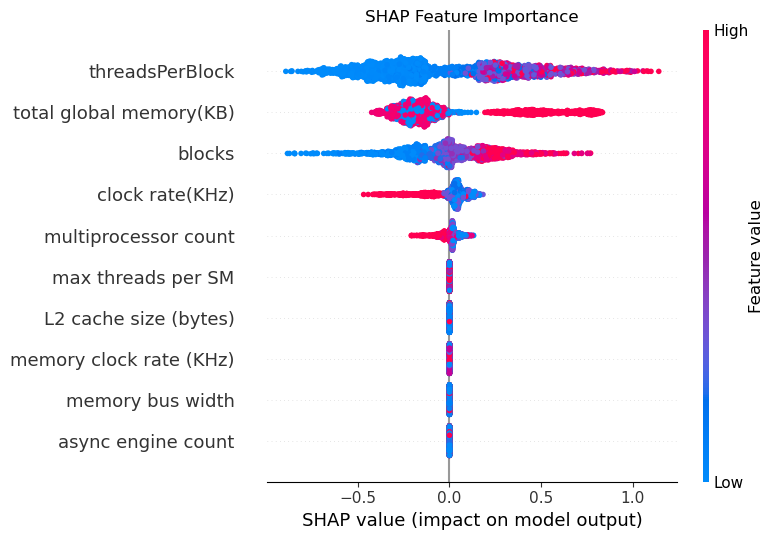

In [49]:
def analyze_feature_importance(model, X_train, exclude, feature_names=None):
    
    if isinstance(exclude, str):
        exclude_idx = feature_names.index(exclude)
    else:
        exclude_idx = exclude
    
    include_names = [name for i, name in enumerate(feature_names) if i != exclude_idx]
    
    importance_values = model.feature_importances_
    importance_dict = {
        name: score for name, score in zip(
            feature_names, 
            importance_values
        ) if name != feature_names[exclude_idx]
    }
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    #running shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # exclude 'elements'
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.drop(columns=[feature_names[exclude_idx]])
    else:
        X_train_filtered = np.delete(X_train, exclude_idx, axis=1)
    
    shap_values_filtered = np.delete(shap_values, exclude_idx, axis=1)
    
    # mean absolute shap values for each input feature
    # absolute value because we want to measure total impact, positive or negative on the comptue time
    mean_shap = pd.DataFrame({
        'Feature': include_names,
        'SHAP_Importance': np.abs(shap_values_filtered).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    

    fig_xgb = plt.figure(figsize=(10, 5))
    importance_df.plot(x='Feature', y='Importance', kind='bar')
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=70)
    plt.tight_layout()
    
    fig_shap = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values_filtered, X_train_filtered, 
                     feature_names=include_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    
    return {
        'xgboost_importance': importance_df,
        'shap_importance': mean_shap,
        'shap_values': shap_values_filtered,
        'figure_xgb': fig_xgb,
        'figure_shap': fig_shap
    }

results = analyze_feature_importance(model, X_train, exclude='elements', feature_names=features)

print("\nTop 5 most important features (XGBoost):")
print(results['xgboost_importance'].head())

print("\nTop 5 most important features (SHAP):")
print(results['shap_importance'].head())

plt.show()
